Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None
SIMPLE  =                    T /FITS header                                     BITPIX  =                   16 /No.Bits per pixel                               NAXIS   =                    2 /No.dimensions                                   NAXIS1  =                  530 /Length X axis                                   NAXIS2  =                  530 /Length Y axis                                   END                                                                                                                                                                                                                                                                                                                                                                           

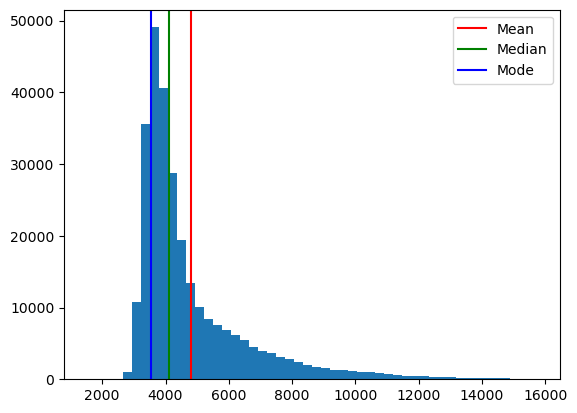

C:\Users\balin\AppData\Local\Temp\ipykernel_31496\514991082.py:40: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(image,cax=colbarframe, label='Counts')


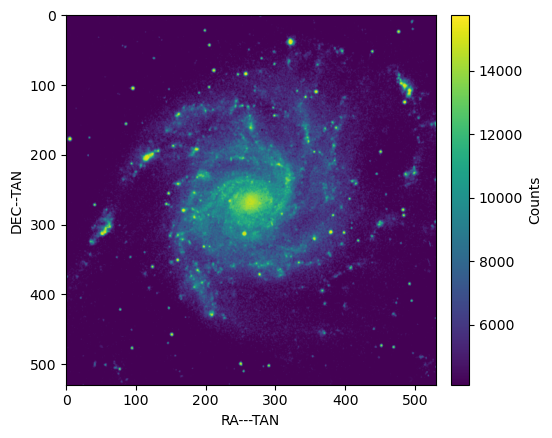

 [astropy.io.fits.verify]


In [1]:
#6.1
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdu=fits.open('m101.fits')
print(hdu.info())
hdr=hdu[0].header
print(hdr[:5])
dat=hdu[0].data
print(dat.shape)
print(dat.dtype)

dat1=dat.flatten()
n,(minval,maxval),mean,var,skew,kurt=stats.describe(dat1)
mode,counts=stats.mode(dat1)
median=np.median(dat1)
print(f"minimum: {minval}, maximum: {maxval}, mean: {mean:.3f}, standard deviation: {var**0.5:.3f}, median: {median}, mode: {mode}")

fig=figure()
frame=fig.add_subplot(1,1,1)
frame.hist(dat1,bins=50)
frame.axvline(mean, label='Mean', color='r')
frame.axvline(median, label='Median', color='g')
frame.axvline(mode, label='Mode', color='b')
frame.legend()
show()

fig2=figure()
frame2=fig2.add_subplot(1,1,1)
dat2=np.asarray(dat,dtype=float)
medi=np.median(dat2)
image=frame2.imshow(dat2,vmin=medi)
frame2.set_xlabel(hdr['CTYPE1'])
frame2.set_ylabel(hdr['CTYPE2'])
divider = make_axes_locatable(frame2)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(image,cax=colbarframe, label='Counts')
show()

hdr["BUNIT"]="Counts"
hdulistout = fits.PrimaryHDU(dat2)
hdulistout.header = hdr
hdulistout.writeto('floatdata.fits', overwrite=True, output_verify='ignore')

In [2]:
#6.3

x=dat[40:60,40:60]
xrms=(((x**2.).sum())/(np.shape(x)[0]*np.shape(x)[1]))**0.5
print(xrms)
print(f'mean: {x.mean()}, standard deviation: {x.std()}')


3473.196650061727
mean: 3463.48, standard deviation: 259.6175256025679


In [3]:
#6.5
hdunoise0=fits.open('noisemap0.fits')
hdunoise1=fits.open('noisemap1.fits')
hdunoise2=fits.open('noisemap2.fits')

noise0=hdunoise0[0].data
noise1=hdunoise1[0].data
noise2=hdunoise2[0].data

noise=np.stack((noise0,noise1,noise2),axis=0)
noisemean=np.mean(noise, axis=0)
noisestd=np.std(noise, axis=0)
totstd1=np.std(noisemean)
totstd2=(noise0.std()**2+noise1.std()**2+noise2.std()**2)**0.5/3
print(totstd1, totstd2)

5.773191380233297 5.770294583366141


In [4]:
#6.6
from astropy.io import fits
from astropy.table import Table
hdul = fits.open('APOGEE_stars.fits')

data = hdul[1].data
colnames = hdul[1].columns.names
data=Table(data=data)
flag=[]
m1=data['STARFLAG']==0
m2=data['ASPCAPFLAG']==0
m3=data['SNR']>10
m4=data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 5
m5=np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
m6=~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
m7=~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])
dataflag=np.where((m1 & m2 & m3 & m4 & m5 & m6 & m7),1,0)
data['DATAFLAG']=dataflag
M=np.where(data['DATAFLAG']==1,data['GAIAEDR3_PHOT_G_MEAN_MAG']+5*np.log10(data['GAIAEDR3_PARALLAX']/1000)+5, -1.0)
data['ABSOLUTE MAGNITUDE']=M

#hdulistout = fits.PrimaryHDU(data)
data.write('APOGEE_update.fits', overwrite=True)

C:\Users\balin\AppData\Local\Temp\ipykernel_31496\235089251.py:19: RuntimeWarning: invalid value encountered in log10
  M=np.where(data['DATAFLAG']==1,data['GAIAEDR3_PHOT_G_MEAN_MAG']+5*np.log10(data['GAIAEDR3_PARALLAX']/1000)+5, -1.0)


42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


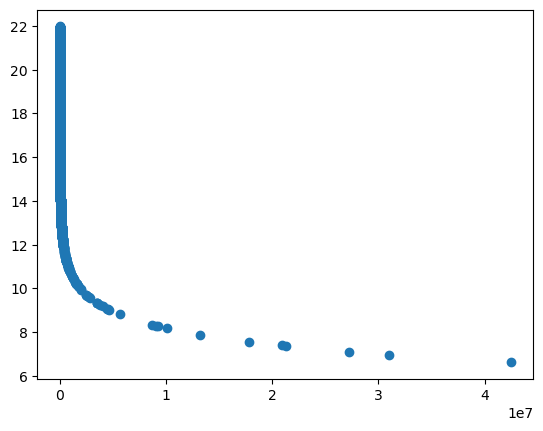

25.68840037029544


In [5]:
#6.7
import pandas as pd

data=pd.read_csv('gaiaTestData.csv')
print(data.phot_g_mean_flux.max())

print(data[data.phot_g_mean_flux==data.phot_g_mean_flux.max()])

data2=data.sort_values(by='phot_g_mean_flux')
fig=figure()
frame=fig.add_subplot(1,1,1)
frame.scatter(data2.phot_g_mean_flux,data2.phot_g_mean_mag)
#frame.yaxis.set_inverted(True)
show()

m0=data2.phot_g_mean_mag+2.5*np.log10(data2.phot_g_mean_flux)
print(m0.mean())

In [13]:
#6.10
import sqlite3 as sqlite
from astroquery.gaia import Gaia

query = """
SELECT source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5 AND
phot_g_mean_mag IS NOT NULL AND
phot_bp_mean_mag IS NOT NULL AND
phot_rp_mean_mag IS NOT NULL
"""
job = Gaia.launch_job(query)
data = job.get_results()

data.write('astroquery_gaia.fits')

In [ ]:
#6.14
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self):
        self.fib=[0,1]
    def func1(self,N):
        fib=self.fib
        while len(fib)<N:
            fib.append(fib[-1]+fib[-2])
        return fib[-1]

    def func2(self,N,M):
        fib=self.fib
        while len(fib)<N:
            fib.append(fib[-1]+fib[-2])
        divs=[]
        for f in fib:
            if f%M==0:
                divs.append(f)
        return divs

fibo=Fibonacci()
print(fibo.func1(100))
print(fibo.func2(100,7))